# Benchmark Analysis

Notebook nay thong ke va phan tich ket qua benchmark tu:
- `benchmarks/results/benchmark_results_summary.txt`
- `benchmarks/results/benchmark_results_boards.txt`

Noi dung:
1. Parse du lieu theo tran
2. Bang tong hop co ban
3. So ban thang theo depth
4. Thoi gian trung binh moi nuoc
5. Cac chi so phu: first-player advantage, upset rate, do dai van
6. Tra cuu ban co ASCII theo `match_id`


In [1]:
import json
import re
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt

_here = Path.cwd()
ROOT = _here if (_here / 'caro_ai').is_dir() else _here.parent
summary_path = ROOT / 'benchmarks' / 'results' / 'benchmark_results_summary.txt'
boards_path = ROOT / 'benchmarks' / 'results' / 'benchmark_results_boards.txt'

print('Summary file:', summary_path)
print('Boards file :', boards_path)
print('Summary exists:', summary_path.exists())
print('Boards exists :', boards_path.exists())

Summary file: /home/dungtv/Caro_AI/benchmarks/results/benchmark_results_summary.txt
Boards file : /home/dungtv/Caro_AI/benchmarks/results/benchmark_results_boards.txt
Summary exists: True
Boards exists : True


In [2]:
def _parse_blocks(text: str):
    blocks = []
    cur = []
    for line in text.splitlines():
        if line.strip() == '':
            if cur:
                blocks.append(cur)
                cur = []
        else:
            cur.append(line)
    if cur:
        blocks.append(cur)
    return blocks

def parse_summary(path: Path) -> pd.DataFrame:
    text = path.read_text(encoding='utf-8')
    rows = []
    for block in _parse_blocks(text):
        kv = {}
        for ln in block:
            if '=' in ln:
                k, v = ln.split('=', 1)
                kv[k.strip()] = v.strip()

        if 'match_id' not in kv:
            continue

        agent_x = json.loads(kv['agent_x'])
        agent_o = json.loads(kv['agent_o'])
        stats = json.loads(kv['stats'])

        row = {
            'match_id': kv['match_id'],
            'winner': kv.get('winner', 'unknown'),
            'winner_code': stats.get('winner_code', None),
            'x_label': agent_x['label'],
            'o_label': agent_o['label'],
            'x_depth': agent_x['config'].get('depth'),
            'o_depth': agent_o['config'].get('depth'),
            'x_avg_move_sec': stats.get('x_avg_move_sec', 0.0),
            'o_avg_move_sec': stats.get('o_avg_move_sec', 0.0),
            'x_moves': stats.get('x_moves', 0),
            'o_moves': stats.get('o_moves', 0),
        }
        row['total_moves'] = row['x_moves'] + row['o_moves']
        row['avg_depth'] = (row['x_depth'] + row['o_depth']) / 2 if row['x_depth'] and row['o_depth'] else None
        rows.append(row)

    df = pd.DataFrame(rows)
    if not df.empty:
        for c in ['x_depth', 'o_depth', 'x_moves', 'o_moves', 'total_moves']:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        for c in ['x_avg_move_sec', 'o_avg_move_sec']:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

def parse_boards(path: Path):
    text = path.read_text(encoding='utf-8')
    blocks = _parse_blocks(text)
    out = {}
    for block in blocks:
        if not block:
            continue
        if not block[0].startswith('match_id='):
            continue
        match_id = block[0].split('=', 1)[1].strip()
        board_ascii = '\n'.join(block[1:])
        out[match_id] = board_ascii
    return out

df = parse_summary(summary_path)
boards = parse_boards(boards_path)

print('Total games:', len(df))
df.head(5)

Total games: 16


,match_id,winner,winner_code,x_label,o_label,x_depth,o_depth,x_avg_move_sec,o_avg_move_sec,x_moves,o_moves,total_moves,avg_depth
0,depth3_vs_depth4_plain__game_1,depth_4,1,depth_3,depth_4,3,4,1.0490,2.7147,36,36,72,3.5
1,depth3_vs_depth4_plain__game_2,depth_4,0,depth_4,depth_3,4,3,3.4816,0.8080,35,34,69,3.5
2,depth3_vs_depth5_plain__game_1,depth_5,1,depth_3,depth_5,3,5,0.6620,6.6543,15,15,30,4.0
3,depth3_vs_depth5_plain__game_2,depth_3,1,depth_5,depth_3,5,3,5.7790,0.7344,13,13,26,4.0
4,depth3_vs_depth6_plain__game_1,depth_6,1,depth_3,depth_6,3,6,0.0707,1.0765,21,21,42,4.5


In [3]:
if df.empty:
    print('Khong co du lieu benchmark de phan tich.')
else:
    print('=== BASIC SUMMARY ===')
    print('Tong so van:', len(df))
    print('Ty le ket qua winner_code (0:X,1:O,2:Draw):')
    print(df['winner_code'].value_counts(normalize=True).sort_index().round(3))
    print('\nTrung binh tong so nuoc/van:', round(df['total_moves'].mean(), 2))
    print('Trung binh thoi gian nuoc X:', round(df['x_avg_move_sec'].mean(), 3), 's')
    print('Trung binh thoi gian nuoc O:', round(df['o_avg_move_sec'].mean(), 3), 's')

=== BASIC SUMMARY ===
Tong so van: 16
Ty le ket qua winner_code (0:X,1:O,2:Draw):
winner_code
0    0.562
1    0.438
Name: proportion, dtype: float64

Trung binh tong so nuoc/van: 39.06
Trung binh thoi gian nuoc X: 1.681 s
Trung binh thoi gian nuoc O: 1.585 s


,depth,games,wins,draws,avg_move_sec,avg_moves,win_rate
0,3,10,3,0,0.365330,19.200000,0.300000
1,4,6,2,0,1.146317,24.500000,0.333333
2,5,6,3,0,2.498050,17.166667,0.500000
3,6,5,5,0,1.337100,22.800000,1.000000
4,7,3,2,0,2.347867,15.000000,0.666667
5,8,2,1,0,6.500700,12.000000,0.500000


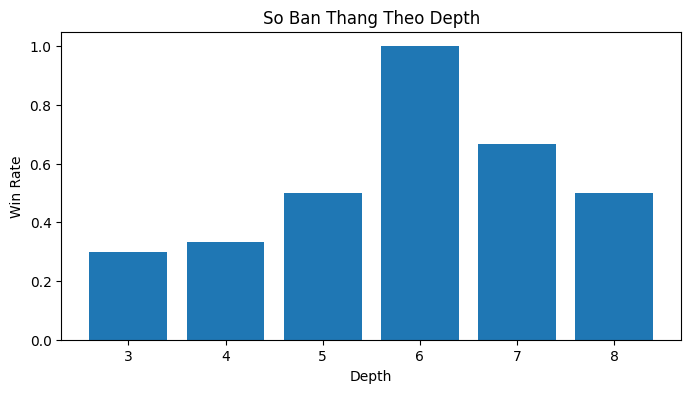

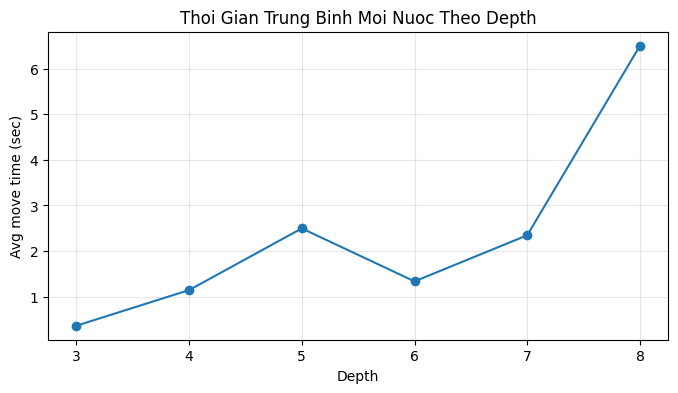

,agent,games,wins,draws,avg_move_sec,avg_moves,win_rate
0,depth_3,10,3,0,0.365330,19.200000,0.300000
1,depth_4,6,2,0,1.146317,24.500000,0.333333
2,depth_5,6,3,0,2.498050,17.166667,0.500000
5,depth_8,2,1,0,6.500700,12.000000,0.500000
4,depth_7,3,2,0,2.347867,15.000000,0.666667
3,depth_6,5,5,0,1.337100,22.800000,1.000000


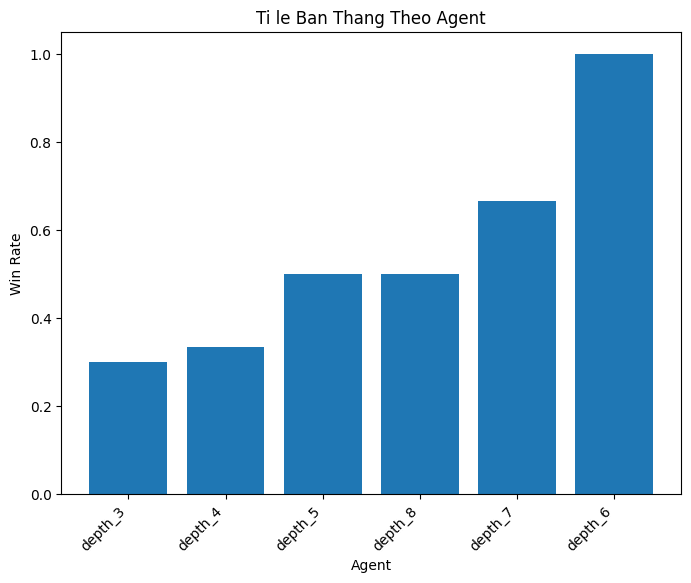

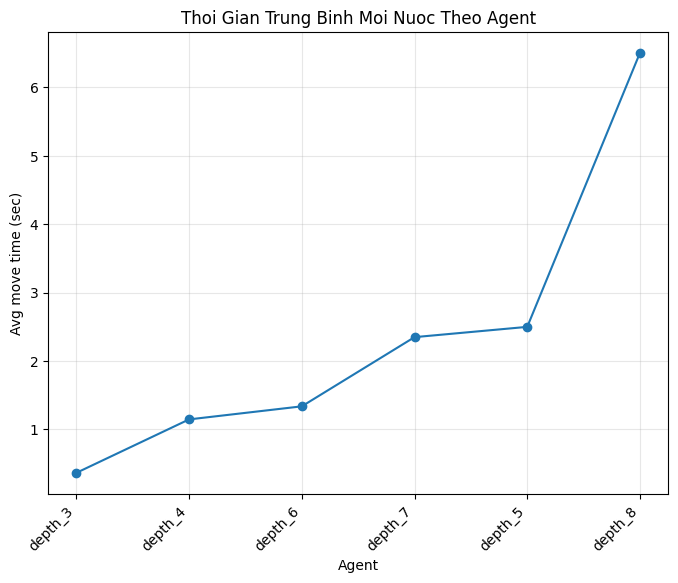

In [4]:
if not df.empty:
    # Expand to per-agent-per-game view
    long_rows = []
    for _, r in df.iterrows():
        x_win = 1 if r['winner'] == r['x_label'] else 0
        o_win = 1 if r['winner'] == r['o_label'] else 0
        x_draw = 1 if r['winner'] == 'draw' else 0
        o_draw = 1 if r['winner'] == 'draw' else 0
        long_rows.append({
            'match_id': r['match_id'], 'side': 'X', 'agent': r['x_label'], 'depth': r['x_depth'],
            'win': x_win, 'draw': x_draw, 'avg_move_sec': r['x_avg_move_sec'], 'moves': r['x_moves']
        })
        long_rows.append({
            'match_id': r['match_id'], 'side': 'O', 'agent': r['o_label'], 'depth': r['o_depth'],
            'win': o_win, 'draw': o_draw, 'avg_move_sec': r['o_avg_move_sec'], 'moves': r['o_moves']
        })
    long_df = pd.DataFrame(long_rows)

    by_depth = long_df.groupby('depth', as_index=False).agg(
        games=('match_id', 'count'),
        wins=('win', 'sum'),
        draws=('draw', 'sum'),
        avg_move_sec=('avg_move_sec', 'mean'),
        avg_moves=('moves', 'mean'),
    )
    by_depth['win_rate'] = by_depth['wins'] / by_depth['games']
    by_depth = by_depth.sort_values('depth')

    display(by_depth)

    plt.figure(figsize=(8, 4))
    plt.bar(by_depth['depth'].astype(str), by_depth['win_rate'])
    plt.title('So Ban Thang Theo Depth')
    plt.xlabel('Depth')
    plt.ylabel('Win Rate')
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(by_depth['depth'], by_depth['avg_move_sec'], marker='o')
    plt.title('Thoi Gian Trung Binh Moi Nuoc Theo Depth')
    plt.xlabel('Depth')
    plt.ylabel('Avg move time (sec)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    
    by_agent = long_df.groupby('agent', as_index=False).agg(
        games=('match_id', 'count'),
        wins=('win', 'sum'),
        draws=('draw', 'sum'),
        avg_move_sec=('avg_move_sec', 'mean'),
        avg_moves=('moves', 'mean'),
    )
    by_agent['win_rate'] = by_agent['wins'] / by_agent['games']
    
    
    by_agent = by_agent.sort_values('win_rate')
    
    display(by_agent)
    
    plt.figure(figsize=(8, 6))
    plt.bar(by_agent['agent'].astype(str), by_agent['win_rate'])
    plt.title('Ti le Ban Thang Theo Agent')
    plt.xlabel('Agent')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Win Rate')
    plt.show()

    by_agent = by_agent.sort_values('avg_move_sec')
    plt.figure(figsize=(8, 6))
    plt.plot(by_agent['agent'], by_agent['avg_move_sec'], marker='o')
    plt.title('Thoi Gian Trung Binh Moi Nuoc Theo Agent')
    plt.xlabel('Agent')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Avg move time (sec)')
    plt.grid(True, alpha=0.3)
    plt.show()


First-player (X) win rate: 0.562
Second-player (O) win rate: 0.438
Draw rate: 0.0
Upset rate (depth thap hon thang): 0.188 (3/16)


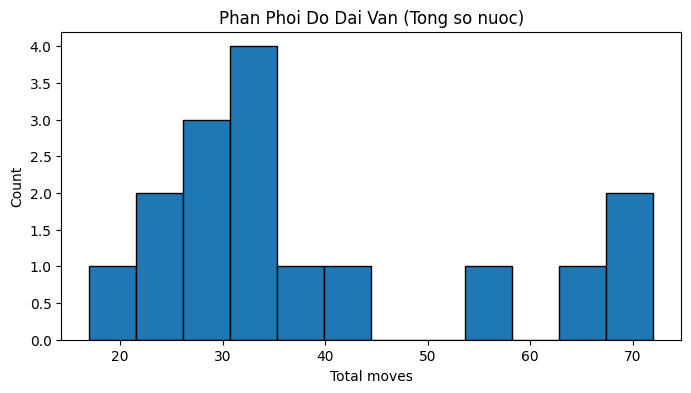

In [5]:
if not df.empty:
    # First-player advantage
    x_win_rate = (df['winner_code'] == 0).mean()
    o_win_rate = (df['winner_code'] == 1).mean()
    draw_rate = (df['winner_code'] == 2).mean()
    print('First-player (X) win rate:', round(x_win_rate, 3))
    print('Second-player (O) win rate:', round(o_win_rate, 3))
    print('Draw rate:', round(draw_rate, 3))

    # Upset rate: depth thap hon thang depth cao hon
    upset = 0
    valid = 0
    for _, r in df.iterrows():
        if r['winner'] == 'draw':
            continue
        valid += 1
        winner_depth = r['x_depth'] if r['winner'] == r['x_label'] else r['o_depth']
        loser_depth = r['o_depth'] if r['winner'] == r['x_label'] else r['x_depth']
        if winner_depth < loser_depth:
            upset += 1
    upset_rate = upset / valid if valid else 0
    print('Upset rate (depth thap hon thang):', round(upset_rate, 3), f'({upset}/{valid})')

    # Game length distribution
    plt.figure(figsize=(8, 4))
    plt.hist(df['total_moves'], bins=12, edgecolor='black')
    plt.title('Phan Phoi Do Dai Van (Tong so nuoc)')
    plt.xlabel('Total moves')
    plt.ylabel('Count')
    plt.show()


In [6]:
# Tra cuu ban co ASCII theo match_id
target_match_id = df['match_id'].iloc[0] if len(df) else None
print('target_match_id =', target_match_id)
if target_match_id:
    print('\n'.join(['=' * 20, target_match_id, '=' * 20]))
    print(boards.get(target_match_id, '[Khong tim thay board ASCII cho match_id nay]'))

target_match_id = depth3_vs_depth4_plain__game_1
depth3_vs_depth4_plain__game_1
[Khong tim thay board ASCII cho match_id nay]


=== PERFORMANCE RANKING (win + speed) ===


,agent,depth,games,wins,draws,win_rate,avg_move_sec,performance_score
3,depth_6,6,5,5,0,1.000000,1.337100,0.745629
0,depth_3,3,10,3,0,0.300000,0.365330,0.545000
4,depth_7,7,3,2,0,0.666667,2.347867,0.487794
2,depth_5,5,6,3,0,0.500000,2.498050,0.376186
5,depth_8,8,2,1,0,0.500000,6.500700,0.344669
1,depth_4,4,6,2,0,0.333333,1.146317,0.328211


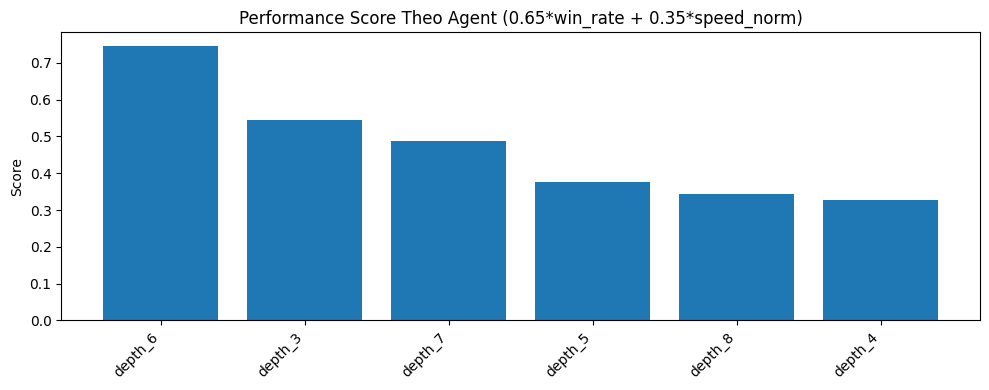

In [7]:
# Performance ranking theo agent/depth (ket hop win + speed)
if not df.empty:
    perf_rows = []
    for _, r in df.iterrows():
        perf_rows.append({
            'agent': r['x_label'],
            'depth': r['x_depth'],
            'win': 1 if r['winner'] == r['x_label'] else 0,
            'draw': 1 if r['winner'] == 'draw' else 0,
            'avg_move_sec': r['x_avg_move_sec'],
            'moves': r['x_moves'],
        })
        perf_rows.append({
            'agent': r['o_label'],
            'depth': r['o_depth'],
            'win': 1 if r['winner'] == r['o_label'] else 0,
            'draw': 1 if r['winner'] == 'draw' else 0,
            'avg_move_sec': r['o_avg_move_sec'],
            'moves': r['o_moves'],
        })

    perf_df = pd.DataFrame(perf_rows)
    ranking = perf_df.groupby(['agent', 'depth'], as_index=False).agg(
        games=('agent', 'count'),
        wins=('win', 'sum'),
        draws=('draw', 'sum'),
        avg_move_sec=('avg_move_sec', 'mean'),
        avg_moves=('moves', 'mean'),
    )
    ranking['win_rate'] = ranking['wins'] / ranking['games']

    # Efficiency score: win_rate uu tien cao, toc do nhanh duoc thuong nhe.
    eps = 1e-9
    ranking['speed_factor'] = 1.0 / (ranking['avg_move_sec'] + eps)
    ranking['speed_factor_norm'] = ranking['speed_factor'] / ranking['speed_factor'].max()
    ranking['performance_score'] = 0.65 * ranking['win_rate'] + 0.35 * ranking['speed_factor_norm']
    ranking = ranking.sort_values(['performance_score', 'win_rate'], ascending=False)

    print('=== PERFORMANCE RANKING (win + speed) ===')
    display(ranking[['agent', 'depth', 'games', 'wins', 'draws', 'win_rate', 'avg_move_sec', 'performance_score']])

    plt.figure(figsize=(10, 4))
    plt.bar(ranking['agent'], ranking['performance_score'])
    plt.xticks(rotation=45, ha='right')
    plt.title('Performance Score Theo Agent (0.65*win_rate + 0.35*speed_norm)')
    plt.ylabel('Score')
    plt.tight_layout()
    plt.show()


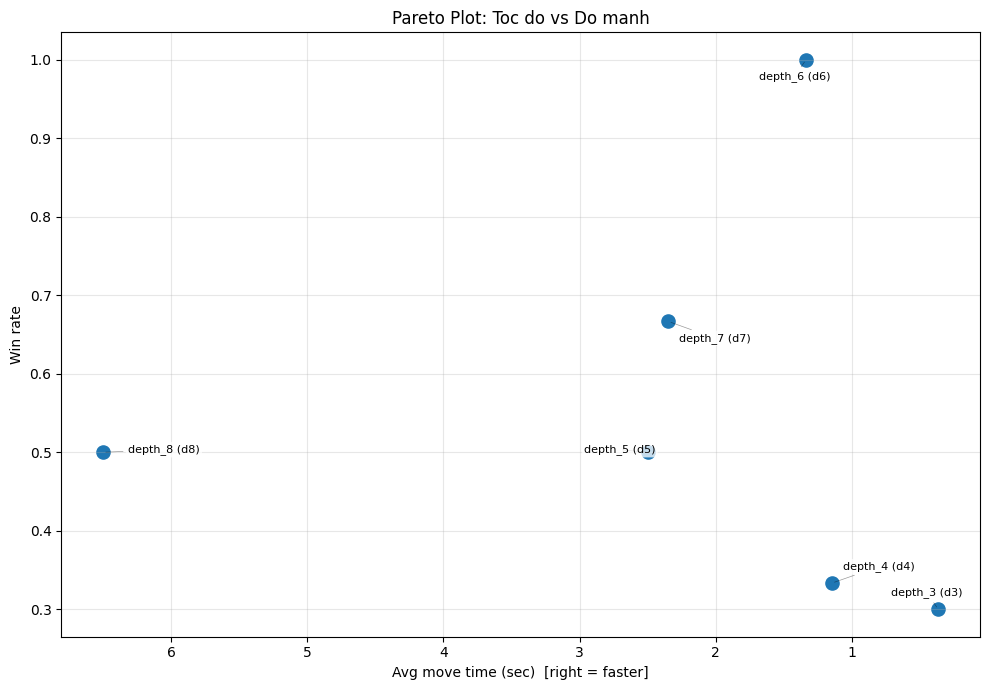

Goi y so sanh: agent nam gan goc tren-phai thuong la can bang tot giua manh va nhanh.


In [8]:
# Pareto view: manh (win_rate cao) va nhanh (avg_move_sec thap)
if not df.empty:
    # reuse ranking from previous cell if exists, otherwise rebuild quickly
    if 'ranking' not in globals():
        perf_rows = []
        for _, r in df.iterrows():
            perf_rows.append({'agent': r['x_label'], 'depth': r['x_depth'], 'win': 1 if r['winner'] == r['x_label'] else 0, 'avg_move_sec': r['x_avg_move_sec']})
            perf_rows.append({'agent': r['o_label'], 'depth': r['o_depth'], 'win': 1 if r['winner'] == r['o_label'] else 0, 'avg_move_sec': r['o_avg_move_sec']})
        perf_df = pd.DataFrame(perf_rows)
        ranking = perf_df.groupby(['agent', 'depth'], as_index=False).agg(games=('agent', 'count'), wins=('win', 'sum'), avg_move_sec=('avg_move_sec', 'mean'))
        ranking['win_rate'] = ranking['wins'] / ranking['games']

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(ranking['avg_move_sec'], ranking['win_rate'], s=90)

    # Reduce label overlap by alternating offsets and adding label boxes.
    rank_for_label = ranking.sort_values(['avg_move_sec', 'win_rate']).reset_index(drop=True)
    offset_pattern = [(-34, 10), (8, 10), (-34, -14), (8, -14), (-46, 0), (18, 0)]
    for i, r in rank_for_label.iterrows():
        ox, oy = offset_pattern[i % len(offset_pattern)]
        ax.annotate(
            f"{r['agent']} (d{int(r['depth'])})",
            (r['avg_move_sec'], r['win_rate']),
            xytext=(ox, oy),
            textcoords='offset points',
            fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.75),
            arrowprops=dict(arrowstyle='-', lw=0.5, alpha=0.4),
        )

    ax.invert_xaxis()
    ax.set_xlabel('Avg move time (sec)  [right = faster]')
    ax.set_ylabel('Win rate')
    ax.set_title('Pareto Plot: Toc do vs Do manh')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('Goi y so sanh: agent nam gan goc tren-phai thuong la can bang tot giua manh va nhanh.')


=== ELO ESTIMATE (approx) ===


,agent,elo_estimate
0,depth_6,1839.870994
1,depth_7,1531.945146
2,depth_5,1460.705449
3,depth_8,1423.718840
4,depth_4,1382.949814
5,depth_3,1360.809757


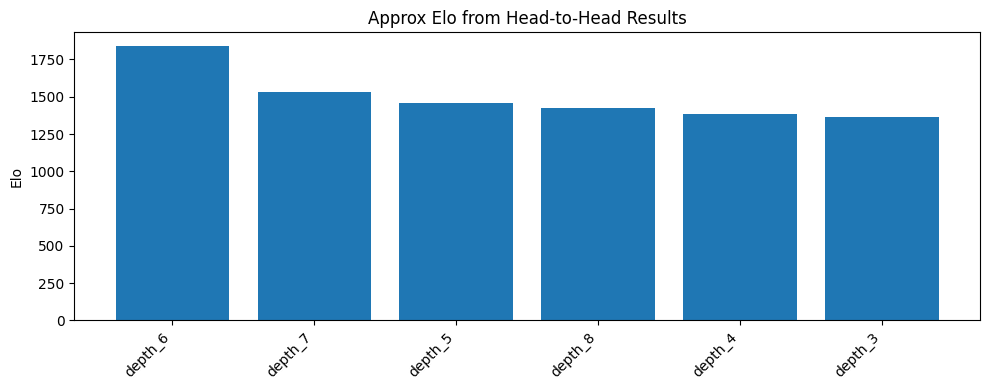

In [9]:
# Elo xap xi tu ket qua doi dau (SGD tren cap ket qua)
import math

if not df.empty:
    # Build match-level outcomes: winner among two agents, draw supported
    matches = []
    for _, r in df.iterrows():
        a = r['x_label']
        b = r['o_label']
        if r['winner'] == 'draw' or r['winner_code'] == 2:
            s_a = 0.5
        elif r['winner'] == a:
            s_a = 1.0
        else:
            s_a = 0.0
        matches.append((a, b, s_a))

    players = sorted(set([m[0] for m in matches] + [m[1] for m in matches]))
    elo = {p: 1500.0 for p in players}
    K = 20.0

    # Multiple passes to stabilize a bit
    for _ in range(20):
        for a, b, s_a in matches:
            ra, rb = elo[a], elo[b]
            ea = 1.0 / (1.0 + 10 ** ((rb - ra) / 400.0))
            delta = K * (s_a - ea)
            elo[a] += delta
            elo[b] -= delta

    elo_df = pd.DataFrame({'agent': list(elo.keys()), 'elo_estimate': list(elo.values())})
    elo_df = elo_df.sort_values('elo_estimate', ascending=False).reset_index(drop=True)

    print('=== ELO ESTIMATE (approx) ===')
    display(elo_df)

    plt.figure(figsize=(10, 4))
    plt.bar(elo_df['agent'], elo_df['elo_estimate'])
    plt.xticks(rotation=45, ha='right')
    plt.title('Approx Elo from Head-to-Head Results')
    plt.ylabel('Elo')
    plt.tight_layout()
    plt.show()


## Difficulty preset selection (Easy / Medium / Hard)

This section suggests **one (agent label, depth)** row from the benchmark summary for each UI tier.

### Criteria

1. **Performance score** (same weighting as above):  
   `0.65 * win_rate + 0.35 * speed_factor_norm`, but **speed is adjusted** for bad spikes: if some games are much slower than the agent’s typical average, the effective speed factor is reduced (worst-game average vs mean).
2. **Elo** (approximate, from the head-to-head cell): used as a **tie-breaker** after the adjusted performance score.
3. **Time budget** on **mean seconds per move** (`avg_move_sec` over games):  
   - **Easy** &lt; 1 s  
   - **Medium** &lt; 4 s  
   - **Hard** &lt; 20 s  
4. **Spike guard**: exclude configs whose **slowest single-game** average move time exceeds `budget × 1.75` for that tier (avoid agents that are usually fast but occasionally stall).

**Prerequisite:** `pandas` (`pd`) must be imported (first code cell). This cell reads `df` from the Jupyter **user namespace** (not only `globals()`, for VS Code / Cursor compatibility), then tries `benchmarks/results/benchmark_results_summary.txt` under `Path.cwd()` and its parent. If `perf_df` / `ranking` or `elo_df` are missing, it rebuilds them from `df`. Tunables: `SPIKE_MULT`, `SPIKE_PENALTY_WEIGHT` in the code cell below.

In [10]:
# Chon agent/depth cho Easy / Medium / Hard (performance + Elo + thoi gian + spike)
import json
from pathlib import Path

SPIKE_MULT = 1.75  # max single-game avg move / tier budget
SPIKE_PENALTY_WEIGHT = 0.35  # giam speed_factor khi worst-game cham hon mean


def _nb_get(name):
    """Bien notebook: Jupyter luu o user_ns; mot so IDE khong dong bo voi globals()."""
    try:
        ip = get_ipython()
    except NameError:
        ip = None
    if ip is not None and name in ip.user_ns:
        return ip.user_ns[name]
    return globals().get(name)


def _resolve_summary_path():
    p = _nb_get('summary_path')
    if isinstance(p, Path) and p.is_file():
        return p
    here = Path.cwd().resolve()
    roots = {here, here.parent}
    for root in roots:
        cand = root / 'benchmarks' / 'results' / 'benchmark_results_summary.txt'
        if cand.is_file():
            return cand
    return None


def _load_df_from_summary(path: Path):
    def _blocks(text: str):
        blocks, cur = [], []
        for line in text.splitlines():
            if line.strip() == '':
                if cur:
                    blocks.append(cur)
                    cur = []
            else:
                cur.append(line)
        if cur:
            blocks.append(cur)
        return blocks

    text = path.read_text(encoding='utf-8')
    rows = []
    for block in _blocks(text):
        kv = {}
        for ln in block:
            if '=' in ln:
                k, v = ln.split('=', 1)
                kv[k.strip()] = v.strip()
        if 'match_id' not in kv:
            continue
        agent_x = json.loads(kv['agent_x'])
        agent_o = json.loads(kv['agent_o'])
        stats = json.loads(kv['stats'])
        row = {
            'match_id': kv['match_id'],
            'winner': kv.get('winner', 'unknown'),
            'winner_code': stats.get('winner_code', None),
            'x_label': agent_x['label'],
            'o_label': agent_o['label'],
            'x_depth': agent_x['config'].get('depth'),
            'o_depth': agent_o['config'].get('depth'),
            'x_avg_move_sec': stats.get('x_avg_move_sec', 0.0),
            'o_avg_move_sec': stats.get('o_avg_move_sec', 0.0),
            'x_moves': stats.get('x_moves', 0),
            'o_moves': stats.get('o_moves', 0),
        }
        row['total_moves'] = row['x_moves'] + row['o_moves']
        row['avg_depth'] = (
            (row['x_depth'] + row['o_depth']) / 2
            if row['x_depth'] and row['o_depth']
            else None
        )
        rows.append(row)
    out = pd.DataFrame(rows)
    if not out.empty:
        for c in ['x_depth', 'o_depth', 'x_moves', 'o_moves', 'total_moves']:
            out[c] = pd.to_numeric(out[c], errors='coerce')
        for c in ['x_avg_move_sec', 'o_avg_move_sec']:
            out[c] = pd.to_numeric(out[c], errors='coerce')
    return out


_df = _nb_get('df')
if _df is None:
    _parse = _nb_get('parse_summary')
    _spath = _resolve_summary_path() or _nb_get('summary_path')
    if isinstance(_spath, Path) and _spath.is_file():
        if callable(_parse):
            _df = _parse(_spath)
        else:
            _df = _load_df_from_summary(_spath)

if _df is None:
    _tried = _resolve_summary_path()
    print(
        'Khong load duoc df. cwd =', Path.cwd(),
        '| summary tim thay:', _tried,
    )
    print(
        'Chay cell import + parse summary, hoac dat file tai '
        '<repo>/benchmarks/results/benchmark_results_summary.txt'
    )
elif _df.empty:
    print('Khong co du lieu benchmark (file summary rong).')
else:
    df = _df

    perf_df = _nb_get('perf_df')
    ranking = _nb_get('ranking')
    if perf_df is None or ranking is None:
        perf_rows = []
        for _, r in df.iterrows():
            perf_rows.append(
                {
                    'agent': r['x_label'],
                    'depth': r['x_depth'],
                    'win': 1 if r['winner'] == r['x_label'] else 0,
                    'draw': 1 if r['winner'] == 'draw' else 0,
                    'avg_move_sec': r['x_avg_move_sec'],
                    'moves': r['x_moves'],
                }
            )
            perf_rows.append(
                {
                    'agent': r['o_label'],
                    'depth': r['o_depth'],
                    'win': 1 if r['winner'] == r['o_label'] else 0,
                    'draw': 1 if r['winner'] == 'draw' else 0,
                    'avg_move_sec': r['o_avg_move_sec'],
                    'moves': r['o_moves'],
                }
            )
        perf_df = pd.DataFrame(perf_rows)
        ranking = perf_df.groupby(['agent', 'depth'], as_index=False).agg(
            games=('agent', 'count'),
            wins=('win', 'sum'),
            draws=('draw', 'sum'),
            avg_move_sec=('avg_move_sec', 'mean'),
            avg_moves=('moves', 'mean'),
        )
        ranking['win_rate'] = ranking['wins'] / ranking['games']
        _eps0 = 1e-9
        ranking['speed_factor'] = 1.0 / (ranking['avg_move_sec'] + _eps0)
        ranking['speed_factor_norm'] = ranking['speed_factor'] / ranking['speed_factor'].max()
        ranking['performance_score'] = (
            0.65 * ranking['win_rate'] + 0.35 * ranking['speed_factor_norm']
        )
        ranking = ranking.sort_values(['performance_score', 'win_rate'], ascending=False)

    elo_df = _nb_get('elo_df')
    if elo_df is None:
        matches = []
        for _, r in df.iterrows():
            a = r['x_label']
            b = r['o_label']
            if r['winner'] == 'draw' or r.get('winner_code') == 2:
                s_a = 0.5
            elif r['winner'] == a:
                s_a = 1.0
            else:
                s_a = 0.0
            matches.append((a, b, s_a))
        players = sorted(set([m[0] for m in matches] + [m[1] for m in matches]))
        elo = {p: 1500.0 for p in players}
        K = 20.0
        for _ in range(20):
            for a, b, s_a in matches:
                ra, rb = elo[a], elo[b]
                ea = 1.0 / (1.0 + 10 ** ((rb - ra) / 400.0))
                delta = K * (s_a - ea)
                elo[a] += delta
                elo[b] -= delta
        elo_df = pd.DataFrame({'agent': list(elo.keys()), 'elo_estimate': list(elo.values())})
        elo_df = elo_df.sort_values('elo_estimate', ascending=False).reset_index(drop=True)

    spike = perf_df.groupby(['agent', 'depth'], as_index=False).agg(
        max_game_avg_move_sec=('avg_move_sec', 'max'),
    )
    sel = ranking.merge(spike, on=['agent', 'depth'], how='left')
    sel = sel.merge(elo_df[['agent', 'elo_estimate']], on='agent', how='left')
    _elo_med = sel['elo_estimate'].median()
    sel['elo_estimate'] = sel['elo_estimate'].fillna(
        _elo_med if pd.notna(_elo_med) else 0.0
    )

    eps = 1e-9
    sel['spike_excess'] = (sel['max_game_avg_move_sec'] - sel['avg_move_sec']).clip(lower=0)
    rel_spike = sel['spike_excess'] / (sel['avg_move_sec'] + eps)
    sel['speed_factor'] = 1.0 / (sel['avg_move_sec'] + eps)
    sel['speed_factor_adj'] = sel['speed_factor'] * (1.0 - SPIKE_PENALTY_WEIGHT * rel_spike.clip(0, 2.0))
    sel['speed_factor_adj'] = sel['speed_factor_adj'].clip(lower=1e-9)
    sel['speed_factor_norm_adj'] = sel['speed_factor_adj'] / sel['speed_factor_adj'].max()
    sel['performance_score_adj'] = 0.65 * sel['win_rate'] + 0.35 * sel['speed_factor_norm_adj']

    tiers = [
        ('easy', 1.0),
        ('medium', 4.0),
        ('hard', 20.0),
    ]

    print('=== DEPTH PRESET SUGGESTIONS (mean move time + spike guard + perf + Elo) ===')
    picks = []
    for name, budget in tiers:
        cap_spike = budget * SPIKE_MULT
        cand = sel[
            (sel['avg_move_sec'] < budget)
            & (sel['max_game_avg_move_sec'] <= cap_spike)
        ].copy()
        cand = cand.sort_values(
            ['performance_score_adj', 'elo_estimate', 'win_rate'],
            ascending=False,
        )
        top = cand.head(5)
        print(f'\n--- {name.upper()} (mean < {budget}s, worst-game avg <= {cap_spike:.2f}s) ---')
        if top.empty:
            print('Khong co ung vien thoa dieu kien; thu noi long SPIKE_MULT hoac budget.')
        else:
            display(
                top[
                    [
                        'agent',
                        'depth',
                        'games',
                        'wins',
                        'win_rate',
                        'avg_move_sec',
                        'max_game_avg_move_sec',
                        'performance_score_adj',
                        'elo_estimate',
                    ]
                ]
            )
            best = top.iloc[0]
            picks.append(
                {
                    'tier': name,
                    'agent': best['agent'],
                    'depth': best['depth'],
                    'win_rate': best['win_rate'],
                    'avg_move_sec': best['avg_move_sec'],
                    'max_game_avg_move_sec': best['max_game_avg_move_sec'],
                    'performance_score_adj': best['performance_score_adj'],
                    'elo_estimate': best['elo_estimate'],
                }
            )

    if picks:
        preset_df = pd.DataFrame(picks)
        print('\n=== TOM TAT LUA CHON (hang dau moi cap) ===')
        display(preset_df)

=== DEPTH PRESET SUGGESTIONS (mean move time + spike guard + perf + Elo) ===

--- EASY (mean < 1.0s, worst-game avg <= 1.75s) ---


,agent,depth,games,wins,win_rate,avg_move_sec,max_game_avg_move_sec,performance_score_adj,elo_estimate
1,depth_3,3,10,3,0.3,0.36533,1.049,0.545,1360.809757



--- MEDIUM (mean < 4.0s, worst-game avg <= 7.00s) ---


,agent,depth,games,wins,win_rate,avg_move_sec,max_game_avg_move_sec,performance_score_adj,elo_estimate
0,depth_6,6,5,5,1.000000,1.337100,1.7625,0.896307,1839.870994
2,depth_7,7,3,2,0.666667,2.347867,3.3953,0.566534,1531.945146
1,depth_3,3,10,3,0.300000,0.365330,1.0490,0.545000,1360.809757
3,depth_5,5,6,3,0.500000,2.498050,6.6543,0.386965,1460.705449
5,depth_4,4,6,2,0.333333,1.146317,3.4816,0.313657,1382.949814



--- HARD (mean < 20.0s, worst-game avg <= 35.00s) ---


,agent,depth,games,wins,win_rate,avg_move_sec,max_game_avg_move_sec,performance_score_adj,elo_estimate
0,depth_6,6,5,5,1.000000,1.337100,1.7625,0.896307,1839.870994
2,depth_7,7,3,2,0.666667,2.347867,3.3953,0.566534,1531.945146
1,depth_3,3,10,3,0.300000,0.365330,1.0490,0.545000,1360.809757
3,depth_5,5,6,3,0.500000,2.498050,6.6543,0.386965,1460.705449
4,depth_8,8,2,1,0.500000,6.500700,7.0671,0.380271,1423.718840



=== TOM TAT LUA CHON (hang dau moi cap) ===


,tier,agent,depth,win_rate,avg_move_sec,max_game_avg_move_sec,performance_score_adj,elo_estimate
0,easy,depth_3,3,0.3,0.36533,1.0490,0.545000,1360.809757
1,medium,depth_6,6,1.0,1.33710,1.7625,0.896307,1839.870994
2,hard,depth_6,6,1.0,1.33710,1.7625,0.896307,1839.870994


=== WIN RATE WITH 95% CI ===


,agent,games,wins,win_rate,ci_low,ci_high
0,depth_6,5,5,1.000000,1.000000,1.000000
1,depth_7,3,2,0.666667,0.133222,1.000000
2,depth_5,6,3,0.500000,0.099917,0.900083
3,depth_8,2,1,0.500000,0.000000,1.000000
4,depth_4,6,2,0.333333,0.000000,0.710536
5,depth_3,10,3,0.300000,0.015969,0.584031


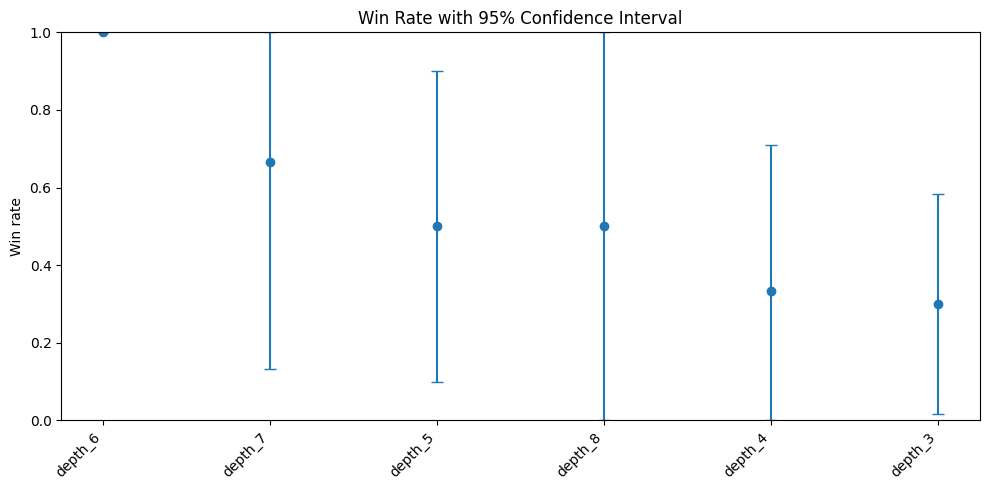

In [11]:
# Confidence interval (95%) cho win rate theo agent
if not df.empty:
    # Per-agent game outcomes
    rows = []
    for _, r in df.iterrows():
        rows.append({'agent': r['x_label'], 'win': 1 if r['winner'] == r['x_label'] else 0, 'game': 1})
        rows.append({'agent': r['o_label'], 'win': 1 if r['winner'] == r['o_label'] else 0, 'game': 1})
    wr = pd.DataFrame(rows).groupby('agent', as_index=False).agg(games=('game', 'sum'), wins=('win', 'sum'))
    wr['win_rate'] = wr['wins'] / wr['games']

    # Normal approximation CI
    z = 1.96
    wr['se'] = (wr['win_rate'] * (1 - wr['win_rate']) / wr['games']).pow(0.5)
    wr['ci_low'] = (wr['win_rate'] - z * wr['se']).clip(lower=0)
    wr['ci_high'] = (wr['win_rate'] + z * wr['se']).clip(upper=1)
    wr = wr.sort_values('win_rate', ascending=False).reset_index(drop=True)

    print('=== WIN RATE WITH 95% CI ===')
    display(wr[['agent', 'games', 'wins', 'win_rate', 'ci_low', 'ci_high']])

    plt.figure(figsize=(10, 5))
    plt.errorbar(
        x=wr['agent'],
        y=wr['win_rate'],
        yerr=[wr['win_rate'] - wr['ci_low'], wr['ci_high'] - wr['win_rate']],
        fmt='o', capsize=4
    )
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.title('Win Rate with 95% Confidence Interval')
    plt.ylabel('Win rate')
    plt.tight_layout()
    plt.show()


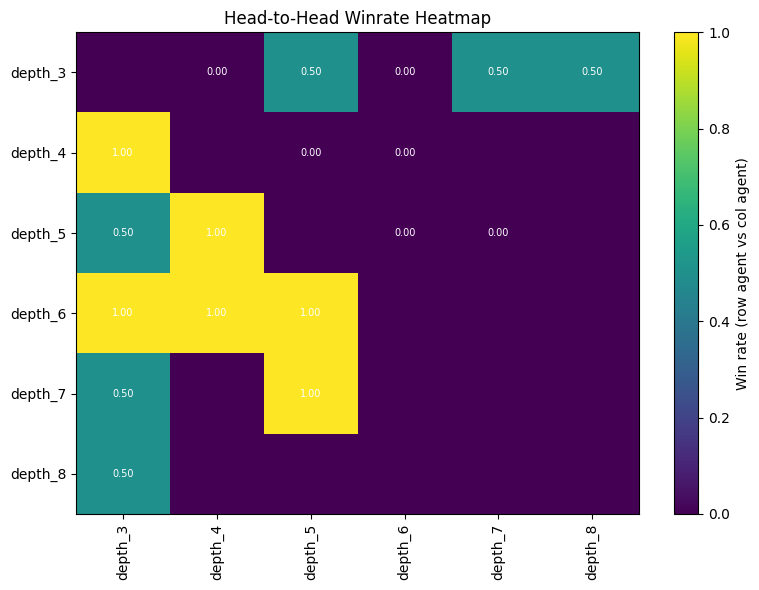

,depth_3,depth_4,depth_5,depth_6,depth_7,depth_8
depth_3,NaN,0.0,0.5,0.0,0.5,0.5
depth_4,1.0,NaN,0.0,0.0,NaN,NaN
depth_5,0.5,1.0,NaN,0.0,0.0,NaN
depth_6,1.0,1.0,1.0,NaN,NaN,NaN
depth_7,0.5,NaN,1.0,NaN,NaN,NaN
depth_8,0.5,NaN,NaN,NaN,NaN,NaN


In [12]:
# Heatmap winrate theo cap depth/profile (agent label)
if not df.empty:
    # Head-to-head matrix: row agent A vs col agent B => P(A wins)
    agents = sorted(set(df['x_label']).union(set(df['o_label'])))
    wins = pd.DataFrame(0.0, index=agents, columns=agents)
    games = pd.DataFrame(0.0, index=agents, columns=agents)

    for _, r in df.iterrows():
        a = r['x_label']
        b = r['o_label']
        games.loc[a, b] += 1
        games.loc[b, a] += 1
        if r['winner'] == 'draw' or r['winner_code'] == 2:
            wins.loc[a, b] += 0.5
            wins.loc[b, a] += 0.5
        elif r['winner'] == a:
            wins.loc[a, b] += 1.0
        else:
            wins.loc[b, a] += 1.0

    # pandas >= 2.x removed `mode.use_inf_as_na`; use explicit safe division.
    denom = games.where(games != 0, pd.NA)
    winrate_mat = wins.divide(denom)

    plt.figure(figsize=(max(8, len(agents)*0.6), max(6, len(agents)*0.45)))
    plt.imshow(winrate_mat.fillna(0.0).values, cmap='viridis', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(label='Win rate (row agent vs col agent)')
    plt.xticks(range(len(agents)), agents, rotation=90)
    plt.yticks(range(len(agents)), agents)
    plt.title('Head-to-Head Winrate Heatmap')

    # annotate values (optional but useful)
    for i in range(len(agents)):
        for j in range(len(agents)):
            val = winrate_mat.iloc[i, j]
            if pd.notna(val):
                plt.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=7, color='white')

    plt.tight_layout()
    plt.show()

    display(winrate_mat)


In [13]:
# Danh gia cap agent 'ngang tai ngang suc' theo head-to-head
if not df.empty:
    pair_rows = []
    for _, r in df.iterrows():
        a, b = sorted([r['x_label'], r['o_label']])
        key = f"{a}__vs__{b}"

        if r['winner'] == 'draw' or r['winner_code'] == 2:
            score_a = 0.5
            score_b = 0.5
        elif r['winner'] == a:
            score_a = 1.0
            score_b = 0.0
        else:
            score_a = 0.0
            score_b = 1.0

        pair_rows.append({
            'pair_key': key,
            'agent_a': a,
            'agent_b': b,
            'score_a': score_a,
            'score_b': score_b,
            'total_moves': r['total_moves'],
            'x_avg_move_sec': r['x_avg_move_sec'],
            'o_avg_move_sec': r['o_avg_move_sec'],
            'game_move_time_mean': (r['x_avg_move_sec'] + r['o_avg_move_sec']) / 2.0,
        })

    pair_df = pd.DataFrame(pair_rows)
    pair_summary = pair_df.groupby(['pair_key', 'agent_a', 'agent_b'], as_index=False).agg(
        games=('pair_key', 'count'),
        score_a_sum=('score_a', 'sum'),
        score_b_sum=('score_b', 'sum'),
        avg_total_moves=('total_moves', 'mean'),
        max_total_moves=('total_moves', 'max'),
        avg_game_move_time=('game_move_time_mean', 'mean'),
    )

    pair_summary['win_rate_a'] = pair_summary['score_a_sum'] / pair_summary['games']
    pair_summary['win_rate_b'] = pair_summary['score_b_sum'] / pair_summary['games']
    pair_summary['balance_gap'] = (pair_summary['win_rate_a'] - 0.5).abs()

    # Balance score: cang gan 50-50 va cang nhieu nuoc thi cang "ngang suc"
    eps = 1e-9
    norm_len = pair_summary['avg_total_moves'] / (pair_summary['avg_total_moves'].max() + eps)
    pair_summary['balance_score'] = 0.7 * (1 - 2 * pair_summary['balance_gap']) + 0.3 * norm_len

    pair_summary = pair_summary.sort_values('balance_score', ascending=False)

    print('=== CAP AGENT NGANG TAI (theo balance_score) ===')
    display(pair_summary[['pair_key', 'games', 'win_rate_a', 'win_rate_b', 'avg_total_moves', 'max_total_moves', 'avg_game_move_time', 'balance_score']])


=== CAP AGENT NGANG TAI (theo balance_score) ===


,pair_key,games,win_rate_a,win_rate_b,avg_total_moves,max_total_moves,avg_game_move_time,balance_score
3,depth_3__vs__depth_7,2,0.5,0.5,31.0,35,0.943925,0.831915
1,depth_3__vs__depth_5,2,0.5,0.5,28.0,30,3.457425,0.819149
4,depth_3__vs__depth_8,2,0.5,0.5,24.0,31,3.282400,0.802128
0,depth_3__vs__depth_4,2,0.0,1.0,70.5,72,2.013325,0.300000
7,depth_5__vs__depth_6,1,0.0,1.0,57.0,57,0.976250,0.242553
6,depth_4__vs__depth_6,2,0.0,1.0,44.5,63,0.705250,0.189362
2,depth_3__vs__depth_6,2,0.0,1.0,39.5,42,0.745825,0.168085
5,depth_4__vs__depth_5,2,0.0,1.0,32.5,34,0.352000,0.138298
8,depth_5__vs__depth_7,1,0.0,1.0,28.0,28,2.148450,0.119149


=== TOP 10 TRAN CO SO NUOC DI NHIEU NHAT ===


,match_id,x_label,o_label,winner,x_depth,o_depth,total_moves,x_avg_move_sec,o_avg_move_sec
0,depth3_vs_depth4_plain__game_1,depth_3,depth_4,depth_4,3,4,72,1.0490,2.7147
1,depth3_vs_depth4_plain__game_2,depth_4,depth_3,depth_4,4,3,69,3.4816,0.8080
13,depth4_vs_depth6_plain__game_2,depth_6,depth_4,depth_6,6,4,63,1.3570,0.2533
14,depth5_vs_depth6_plain__game_2,depth_6,depth_5,depth_6,6,5,57,1.4309,0.5216
4,depth3_vs_depth6_plain__game_1,depth_3,depth_6,depth_6,3,6,42,0.0707,1.0765
5,depth3_vs_depth6_plain__game_2,depth_6,depth_3,depth_6,6,3,37,1.7625,0.0736
6,depth3_vs_depth7_plain__game_1,depth_3,depth_7,depth_3,3,7,35,0.0673,1.3611
10,depth4_vs_depth5_plain__game_1,depth_4,depth_5,depth_5,4,5,34,0.1378,0.5159
11,depth4_vs_depth5_plain__game_2,depth_5,depth_4,depth_5,5,4,31,0.6159,0.1384
8,depth3_vs_depth8_plain__game_1,depth_3,depth_8,depth_3,3,8,31,0.0729,5.9343


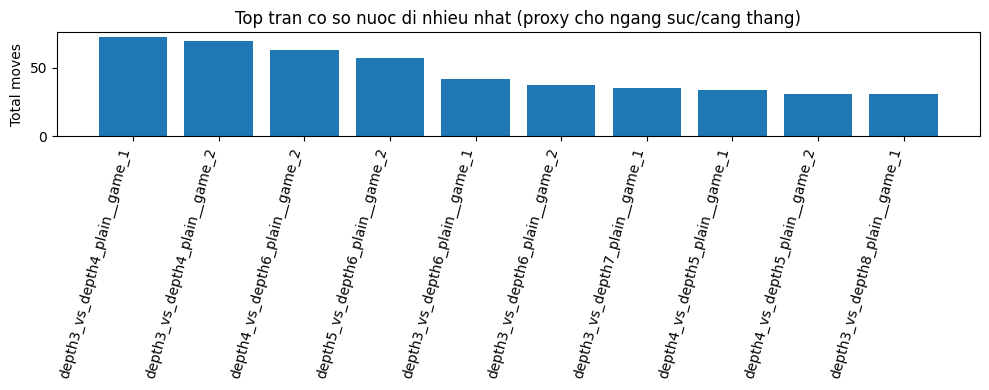

=== TOP 10 TRAN CO SO NUOC DI IT NHAT ===


,match_id,x_label,o_label,winner,x_depth,o_depth,total_moves,x_avg_move_sec,o_avg_move_sec
9,depth3_vs_depth8_plain__game_2,depth_8,depth_3,depth_8,8,3,17,7.0671,0.0553
3,depth3_vs_depth5_plain__game_2,depth_5,depth_3,depth_3,5,3,26,5.7790,0.7344
12,depth4_vs_depth6_plain__game_1,depth_4,depth_6,depth_6,4,6,26,0.1521,1.0586
7,depth3_vs_depth7_plain__game_2,depth_7,depth_3,depth_7,7,3,27,2.2872,0.0601
15,depth5_vs_depth7_plain__game_1,depth_5,depth_7,depth_7,5,7,28,0.9016,3.3953
2,depth3_vs_depth5_plain__game_1,depth_3,depth_5,depth_5,3,5,30,0.6620,6.6543
8,depth3_vs_depth8_plain__game_1,depth_3,depth_8,depth_3,3,8,31,0.0729,5.9343
11,depth4_vs_depth5_plain__game_2,depth_5,depth_4,depth_5,5,4,31,0.6159,0.1384
10,depth4_vs_depth5_plain__game_1,depth_4,depth_5,depth_5,4,5,34,0.1378,0.5159
6,depth3_vs_depth7_plain__game_1,depth_3,depth_7,depth_3,3,7,35,0.0673,1.3611


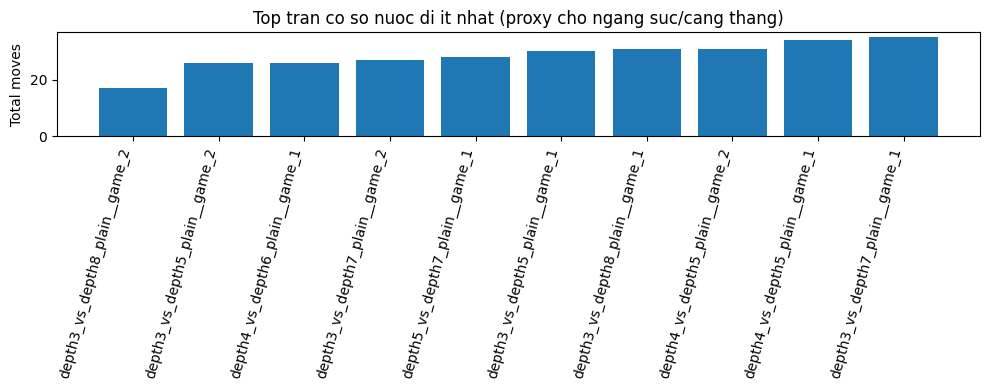

=== CAP CAN BANG (40%-60%) VA CO TRAN DAI ===


,pair_key,games,win_rate_a,win_rate_b,avg_total_moves,max_total_moves,balance_score
3,depth_3__vs__depth_7,2,0.5,0.5,31.0,35,0.831915
1,depth_3__vs__depth_5,2,0.5,0.5,28.0,30,0.819149
4,depth_3__vs__depth_8,2,0.5,0.5,24.0,31,0.802128


In [14]:
# Top tran 'can nao' theo so nuoc di nhieu nhat
if not df.empty:
    top_long_games = df.sort_values('total_moves', ascending=False).head(10).copy()
    top_long_games = top_long_games[['match_id', 'x_label', 'o_label', 'winner', 'x_depth', 'o_depth', 'total_moves', 'x_avg_move_sec', 'o_avg_move_sec']]

    print('=== TOP 10 TRAN CO SO NUOC DI NHIEU NHAT ===')
    display(top_long_games)

    plt.figure(figsize=(10, 4))
    plt.bar(top_long_games['match_id'], top_long_games['total_moves'])
    plt.xticks(rotation=75, ha='right')
    plt.title('Top tran co so nuoc di nhieu nhat (proxy cho ngang suc/cang thang)')
    plt.ylabel('Total moves')
    plt.tight_layout()
    plt.show()
    
    
    top_sort_games = df.sort_values('total_moves').head(10).copy()
    top_sort_games = top_sort_games[['match_id', 'x_label', 'o_label', 'winner', 'x_depth', 'o_depth', 'total_moves', 'x_avg_move_sec', 'o_avg_move_sec']]

    print('=== TOP 10 TRAN CO SO NUOC DI IT NHAT ===')
    display(top_sort_games)

    plt.figure(figsize=(10, 4))
    plt.bar(top_sort_games['match_id'], top_sort_games['total_moves'])
    plt.xticks(rotation=75, ha='right')
    plt.title('Top tran co so nuoc di it nhat (proxy cho ngang suc/cang thang)')
    plt.ylabel('Total moves')
    plt.tight_layout()
    plt.show()

    # Cac cap vua can bang vua dai tran (thuc dung)
    if 'pair_summary' in globals():
        close_pairs = pair_summary[(pair_summary['win_rate_a'].between(0.4, 0.6)) & (pair_summary['games'] >= 2)]
        close_pairs = close_pairs.sort_values(['avg_total_moves', 'balance_score'], ascending=False)
        print('=== CAP CAN BANG (40%-60%) VA CO TRAN DAI ===')
        display(close_pairs[['pair_key', 'games', 'win_rate_a', 'win_rate_b', 'avg_total_moves', 'max_total_moves', 'balance_score']])


=== Tong Thoi Gian Moi Tran Trung Binh Theo Agent ===


,agent,depth,games,wins,win_rate,avg_game_total_time_sec,median_game_total_time_sec,avg_moves,finishing_score
3,depth_6,6,5,5,1.000000,30.955180,33.48750,22.800000,0.857895
4,depth_7,7,3,2,0.666667,34.231233,32.02080,15.000000,0.706667
5,depth_8,8,2,1,0.500000,76.309200,76.30920,12.000000,0.650000
2,depth_5,5,6,3,0.500000,36.798900,13.61360,17.166667,0.559709
0,depth_3,3,10,3,0.300000,9.112420,1.40475,19.200000,0.397500
1,depth_4,4,6,2,0.333333,38.972233,5.09745,24.500000,0.380272


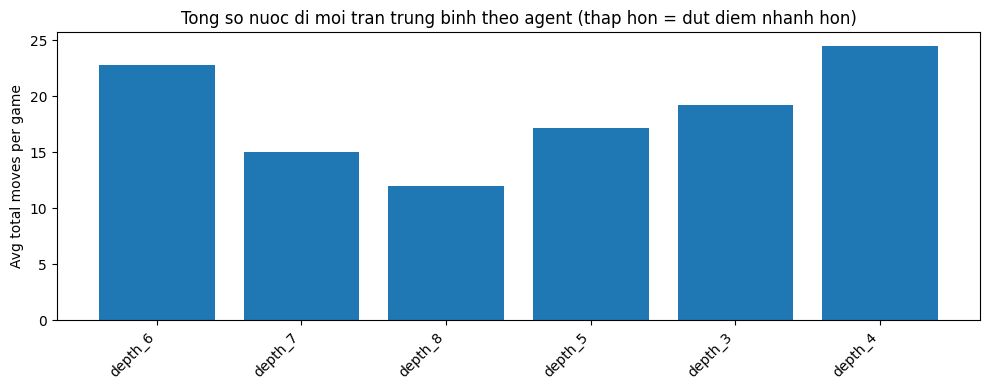

In [15]:
# Tong thoi gian moi tran trung binh theo agent (proxy kha nang dut diem)
# Dinh nghia: game_total_time_agent ~= avg_move_sec * moves cua agent trong tran
if not df.empty:
    finish_rows = []
    for _, r in df.iterrows():
        finish_rows.append({
            'agent': r['x_label'],
            'depth': r['x_depth'],
            'game_total_time_sec': float(r['x_avg_move_sec']) * float(r['x_moves']),
            'moves': r['x_moves'],
            'won': 1 if r['winner'] == r['x_label'] else 0,
        })
        finish_rows.append({
            'agent': r['o_label'],
            'depth': r['o_depth'],
            'game_total_time_sec': float(r['o_avg_move_sec']) * float(r['o_moves']),
            'moves': r['o_moves'],
            'won': 1 if r['winner'] == r['o_label'] else 0,
        })

    finish_df = pd.DataFrame(finish_rows)
    finish_summary = finish_df.groupby(['agent', 'depth'], as_index=False).agg(
        games=('agent', 'count'),
        wins=('won', 'sum'),
        avg_game_total_time_sec=('game_total_time_sec', 'mean'),
        median_game_total_time_sec=('game_total_time_sec', 'median'),
        avg_moves=('moves', 'mean'),
    )
    finish_summary['win_rate'] = finish_summary['wins'] / finish_summary['games']

    # Chi so dut diem: thang cao, tong thoi gian/van thap
    eps = 1e-9
    speed_finish = 1.0 / (finish_summary['avg_moves'] + eps)
    speed_finish_norm = speed_finish / speed_finish.max()
    finish_summary['finishing_score'] = 0.7 * finish_summary['win_rate'] + 0.3 * speed_finish_norm
    finish_summary = finish_summary.sort_values('finishing_score', ascending=False)

    print('=== Tong Thoi Gian Moi Tran Trung Binh Theo Agent ===')
    display(finish_summary[['agent', 'depth', 'games', 'wins', 'win_rate', 'avg_game_total_time_sec', 'median_game_total_time_sec', 'avg_moves', 'finishing_score']])

    plt.figure(figsize=(10, 4))
    plt.bar(finish_summary['agent'], finish_summary['avg_moves'])
    plt.xticks(rotation=45, ha='right')
    plt.title('Tong so nuoc di moi tran trung binh theo agent (thap hon = dut diem nhanh hon)')
    plt.ylabel('Avg total moves per game')
    plt.tight_layout()
    plt.show()
